# Smart Manufacturing Equipment Failure Prediction & Maintenance Cost Control

**Type:** Supervised Machine Learning — Binary Classification
**Dataset:** AI4I 2020 Predictive Maintenance Dataset (~10,000 records)
**Goal:** Predict machine failure probability from sensor data, convert it into a
risk level, health score, and maintenance recommendation, and export everything
for a Power BI dashboard.

**Notebook structure:** every stage below follows
`explanation → code → output → inference → decision`, so this notebook can be
read as a technical report, not just a script.


## 1. Problem Statement

Manufacturing machines run continuously and emit sensor readings (temperature, rotational speed, torque, tool wear). Unplanned failures cause downtime, emergency repairs, and higher maintenance cost.

**Problem we are solving:** Can we use machine sensor data to predict failure *before* it happens, so maintenance can be scheduled proactively instead of reactively?

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

pd.set_option('display.max_columns', None)
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 2. Data Dictionary

| Column | Description | Data Type | Role |
|---|---|---|---|
| UDI | Unique record identifier | Integer | Identifier (drop) |
| Product ID | Product/machine identifier | Categorical | Identifier (drop) |
| Type | Machine quality variant: Low (L), Medium (M), High (H) | Categorical | Feature |
| Air temperature [K] | Ambient air temperature | Numerical | Feature |
| Process temperature [K] | Machine process temperature | Numerical | Feature |
| Rotational speed [rpm] | Machine rotational speed | Numerical | Feature |
| Torque [Nm] | Machine torque | Numerical | Feature |
| Tool wear [min] | Cumulative tool usage/wear | Numerical | Feature |
| Machine failure | 1 if the machine failed, else 0 | Binary | **Target** |
| TWF | Tool Wear Failure flag | Binary | Failure-mode indicator (leakage risk) |
| HDF | Heat Dissipation Failure flag | Binary | Failure-mode indicator (leakage risk) |
| PWF | Power Failure flag | Binary | Failure-mode indicator (leakage risk) |
| OSF | Overstrain Failure flag | Binary | Failure-mode indicator (leakage risk) |
| RNF | Random Failure flag | Binary | Failure-mode indicator (leakage risk) |

> **Important note on leakage:** `TWF, HDF, PWF, OSF, RNF` are sub-flags that record *which* failure mode occurred. They are only known **after** a failure has already happened, so they cannot be used as predictive features (that would be data leakage). We will drop them from the feature set and use them only for exploratory 'failure type' analysis.

## 3. Data Loading & Understanding

In [2]:
df = pd.read_csv('../data/raw/raw_data.csv')
print('Shape:', df.shape)
df.head()


Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('Duplicate Product IDs:', df['Product ID'].duplicated().sum())


Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0
Duplicate Product IDs: 0


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [6]:
print('Categorical distribution - Type:')
print(df['Type'].value_counts())
print('\nTarget distribution - Machine failure:')
print(df['Machine failure'].value_counts())
print(df['Machine failure'].value_counts(normalize=True) * 100)


Categorical distribution - Type:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Target distribution - Machine failure:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


**Observation:** The dataset has 10,000 rows, 14 columns, no missing values,
and no duplicate rows. `Type` has 3 categories (L, M, H). The target
`Machine failure` is heavily **imbalanced** — failures are the minority class
(roughly 3–4% of records), which is realistic for manufacturing failure data.

**Decision:** Because of imbalance, we will use a **stratified train/test split**
and prioritize **Recall / F1 / ROC-AUC** over raw Accuracy when comparing models,
and use `class_weight='balanced'` / `scale_pos_weight` where applicable.

## 4. Complete EDA

### 4A. Target Analysis

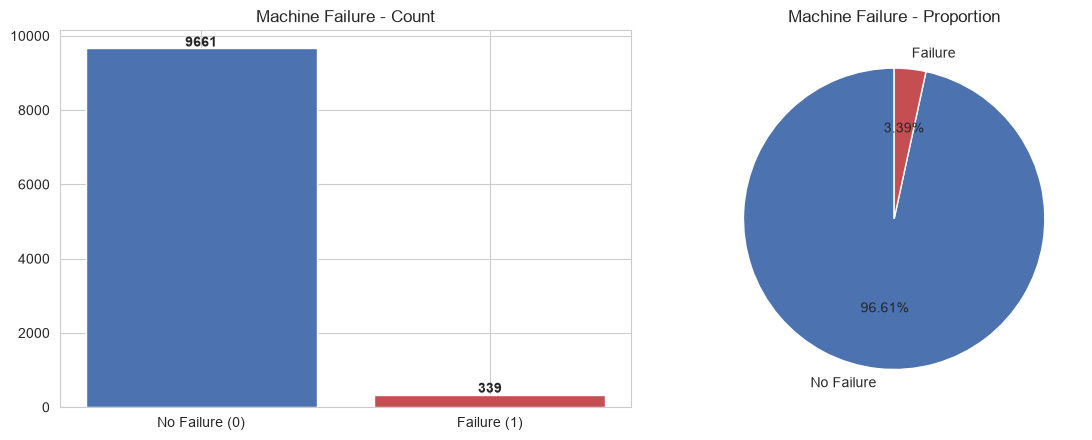

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

counts = df['Machine failure'].value_counts().sort_index()
axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('Machine Failure - Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Failure', 'Failure'], autopct='%1.2f%%',
            colors=['#4C72B0', '#C44E52'], startangle=90)
axes[1].set_title('Machine Failure - Proportion')

plt.tight_layout()
plt.savefig('../figures/01_target_distribution.png', bbox_inches='tight')
plt.show()


**Observation:** Only about 3.4% of machines failed. This is a strongly
imbalanced binary classification problem.

**Decision:** Confirmed — stratified split, imbalance-aware modelling, and
recall-focused evaluation are required (see Section 9).

### 4B. Univariate Analysis — Numerical Sensor Variables

For each key numerical variable we look at its distribution, spread, and
outliers together in a single grid, as required.

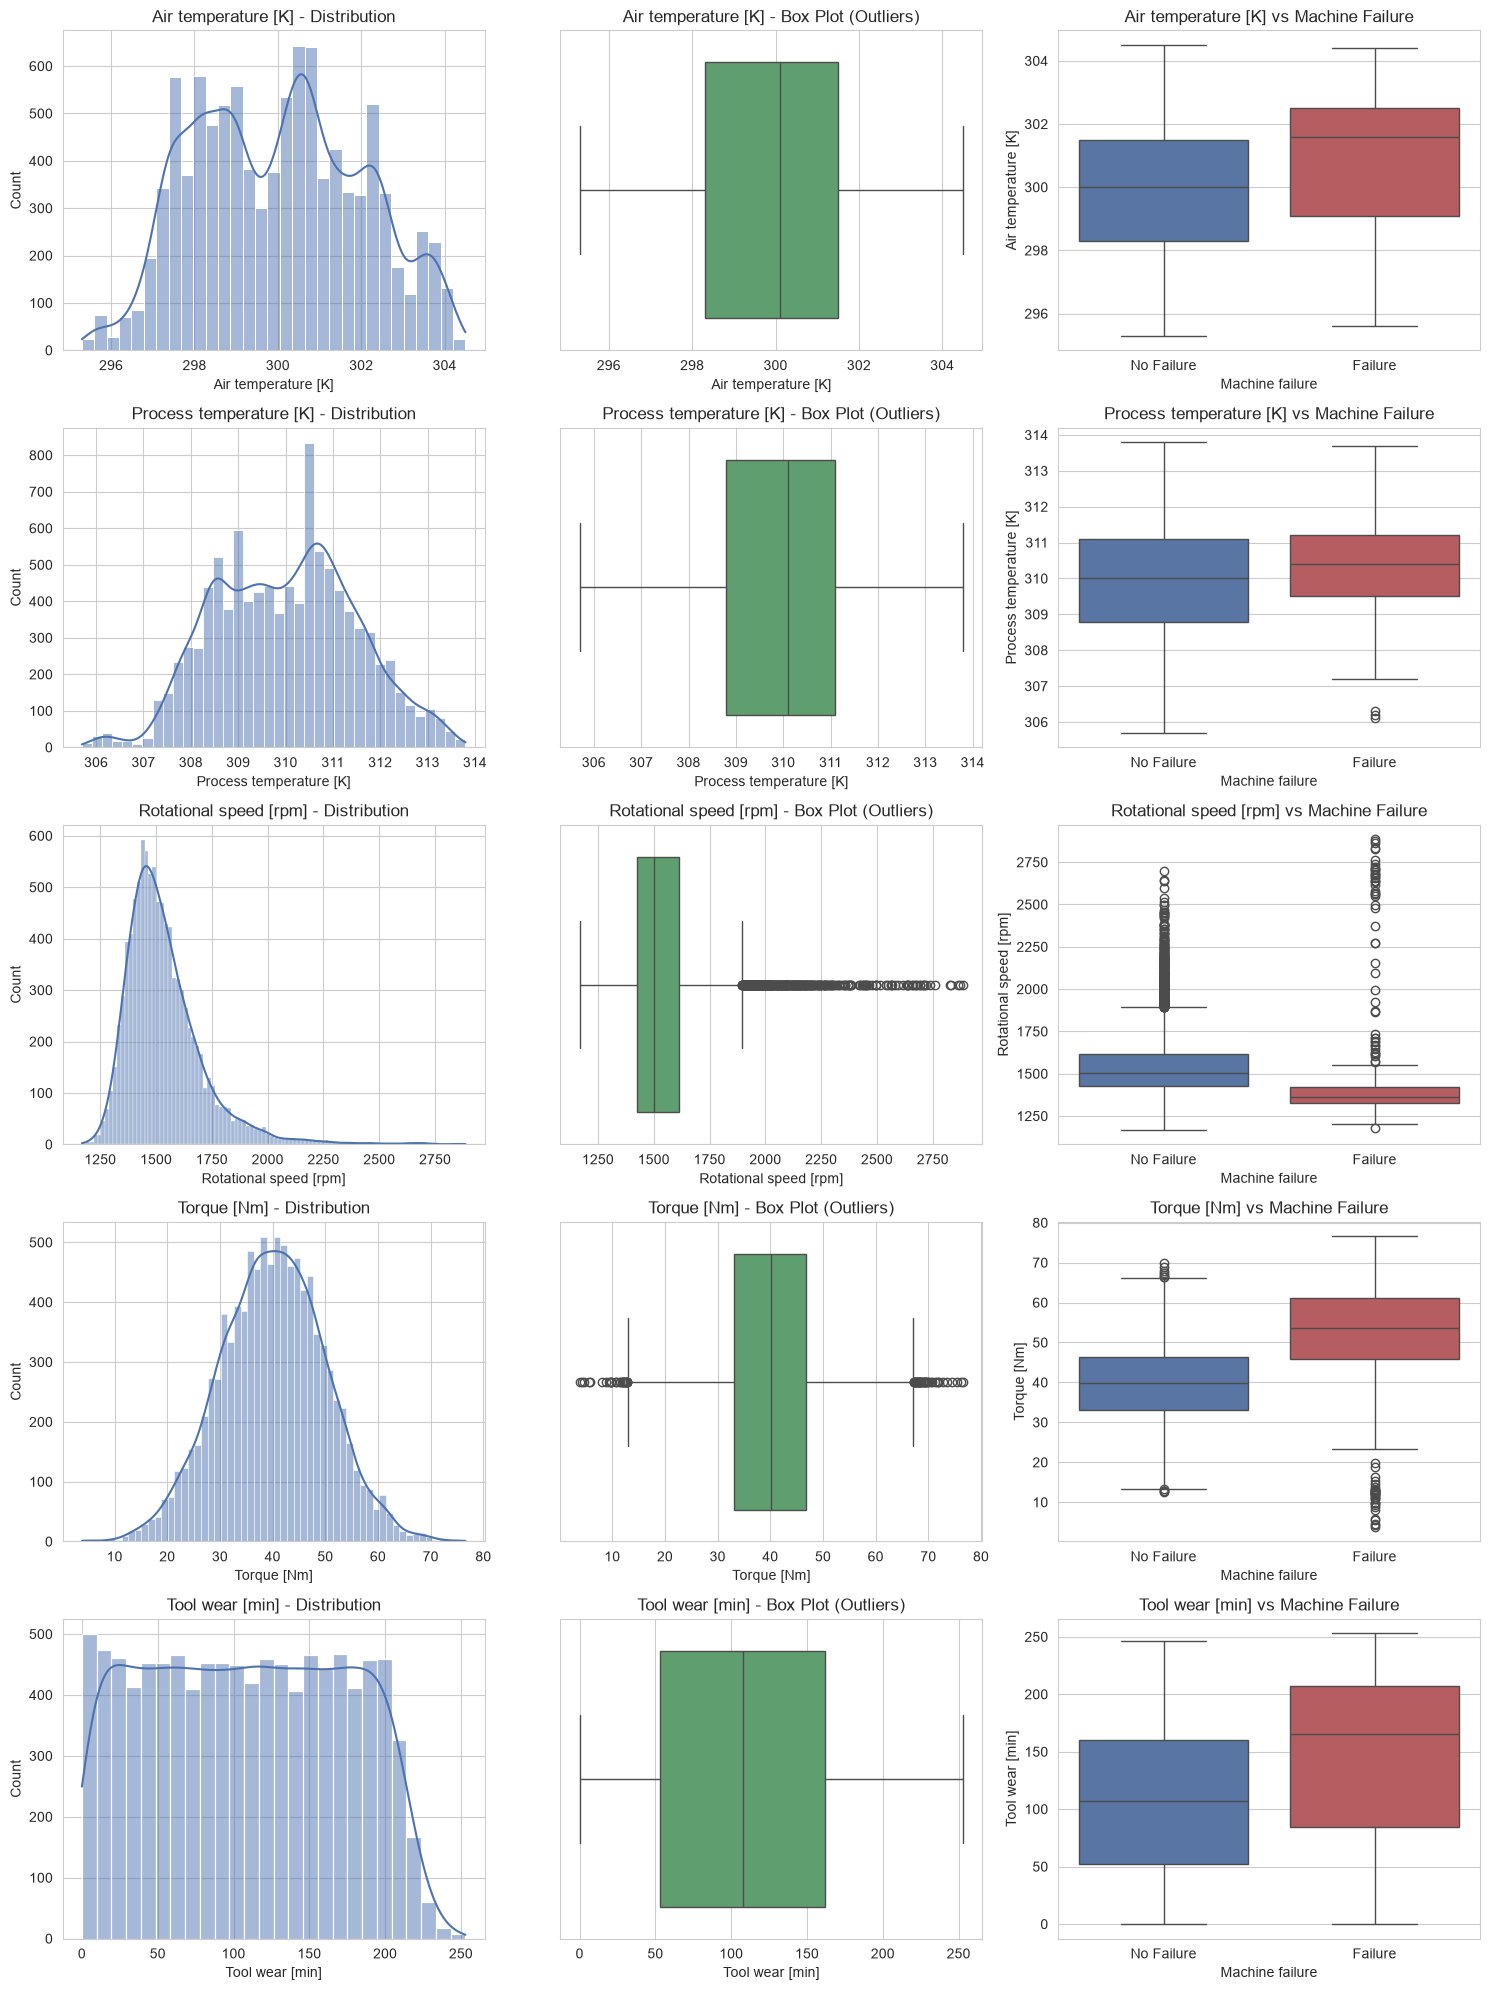

In [8]:
num_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
            'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(len(num_cols), 3, figsize=(15, 4*len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='#4C72B0')
    axes[i, 0].set_title(f'{col} - Distribution')

    # Box plot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='#55A868')
    axes[i, 1].set_title(f'{col} - Box Plot (Outliers)')

    # Failure-wise comparison
    sns.boxplot(x='Machine failure', y=col, data=df, ax=axes[i, 2], palette=['#4C72B0', '#C44E52'])
    axes[i, 2].set_title(f'{col} vs Machine Failure')
    axes[i, 2].set_xticklabels(['No Failure', 'Failure'])

plt.tight_layout()
plt.savefig('../figures/02_univariate_numerical_grid.png', bbox_inches='tight')
plt.show()


**Observation:**
- `Torque` and `Tool wear` show visibly higher spread/values among failed machines
  compared to non-failed ones — both distributions shift right for failures.
- `Rotational speed` shows a mild inverse relationship: unusually low speed combined
  with high torque tends to co-occur with failure (mechanical overload).
- `Air/Process temperature` are fairly normal, tightly distributed, with process
  temperature consistently ~10K above air temperature.
- A handful of box-plot outliers exist in `Rotational speed` and `Torque`, but
  they fall within physically plausible sensor ranges (not obvious sensor errors).

**Decision:** All five numerical variables are retained as candidate predictive
features. Outliers are kept (see Section 6) since they represent genuine extreme
operating conditions relevant to predicting failure, not data entry errors.

### 4C. Univariate Analysis — Categorical Variable (`Type`)

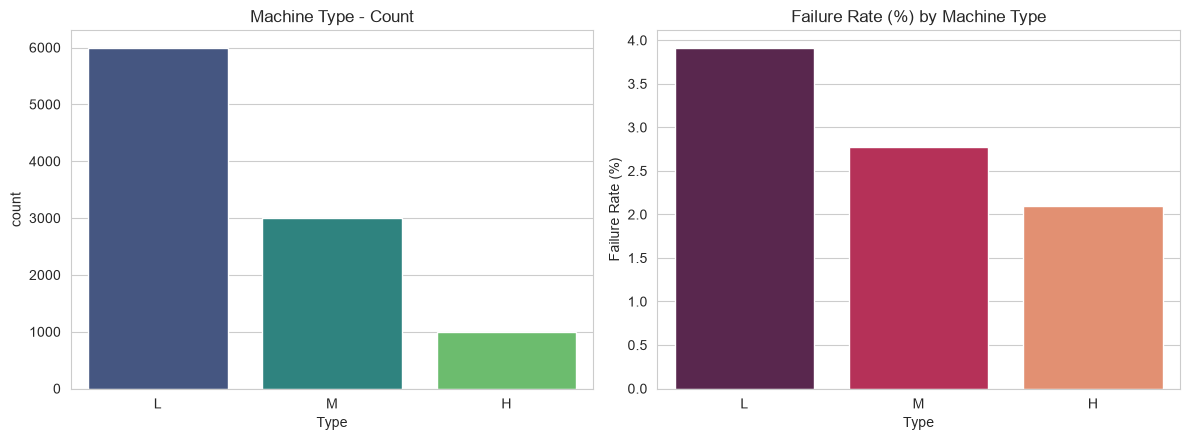

Type
L    3.916667
M    2.769436
H    2.093719
Name: Machine failure, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

type_counts = df['Type'].value_counts()
sns.countplot(x='Type', data=df, order=type_counts.index, ax=axes[0], palette='viridis')
axes[0].set_title('Machine Type - Count')

fail_rate_by_type = df.groupby('Type')['Machine failure'].mean().sort_values(ascending=False) * 100
sns.barplot(x=fail_rate_by_type.index, y=fail_rate_by_type.values, ax=axes[1], palette='rocket')
axes[1].set_title('Failure Rate (%) by Machine Type')
axes[1].set_ylabel('Failure Rate (%)')

plt.tight_layout()
plt.savefig('../figures/03_type_analysis.png', bbox_inches='tight')
plt.show()
print(fail_rate_by_type)


**Observation:** 'Low' quality-variant machines (`Type = L`) are the most
common in the dataset and also show a noticeably higher failure rate than
'Medium' or 'High' variants — consistent with lower-quality components failing
more often.

**Decision:** `Type` is retained and will be one-hot encoded as a predictive
feature.

### 4D. Bivariate Analysis — Sensor Variables vs Machine Failure

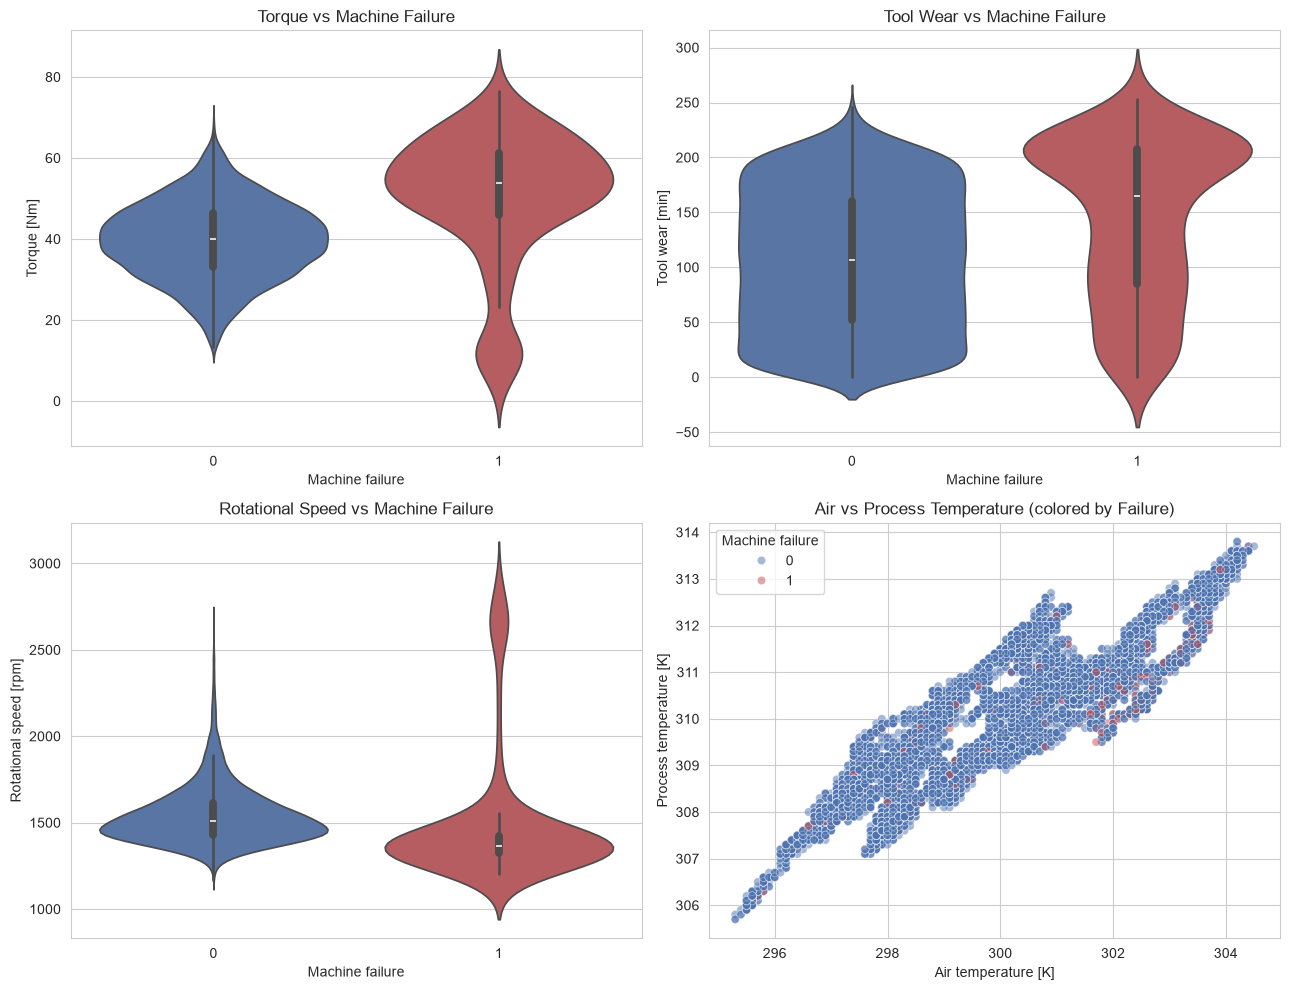

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.violinplot(x='Machine failure', y='Torque [Nm]', data=df, ax=axes[0,0], palette=['#4C72B0','#C44E52'])
axes[0,0].set_title('Torque vs Machine Failure')

sns.violinplot(x='Machine failure', y='Tool wear [min]', data=df, ax=axes[0,1], palette=['#4C72B0','#C44E52'])
axes[0,1].set_title('Tool Wear vs Machine Failure')

sns.violinplot(x='Machine failure', y='Rotational speed [rpm]', data=df, ax=axes[1,0], palette=['#4C72B0','#C44E52'])
axes[1,0].set_title('Rotational Speed vs Machine Failure')

sns.scatterplot(x='Air temperature [K]', y='Process temperature [K]', hue='Machine failure',
                 data=df, ax=axes[1,1], alpha=0.5, palette=['#4C72B0','#C44E52'])
axes[1,1].set_title('Air vs Process Temperature (colored by Failure)')

plt.tight_layout()
plt.savefig('../figures/04_bivariate_grid.png', bbox_inches='tight')
plt.show()


**Observation:** Failure cases cluster at higher torque and higher tool wear.
Rotational speed shows more spread (both very low and very high speeds) among
failures. Air vs process temperature stay tightly correlated regardless of
failure status, suggesting their *difference* (not their individual values)
may carry more signal — this motivates an engineered feature (Section 7).

**Decision:** Torque and Tool Wear are strong candidate predictors. Temperature
difference will be engineered and tested.

### 4E. Multivariate Analysis

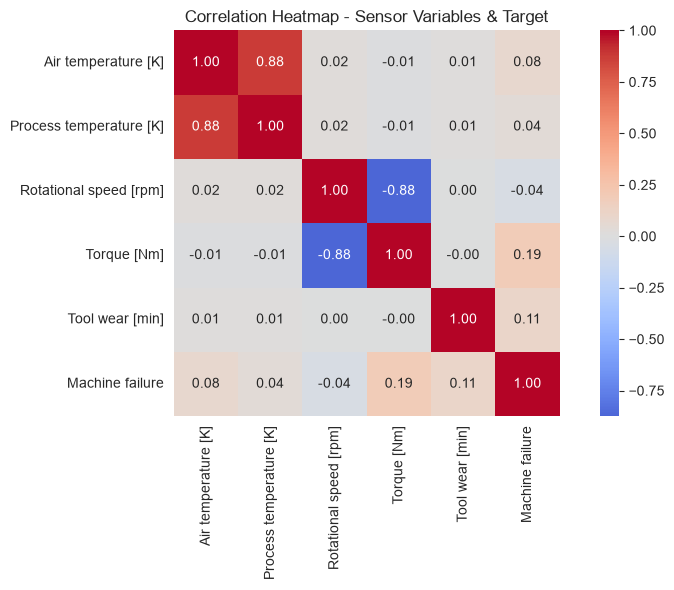

In [11]:
plt.figure(figsize=(9, 6))
corr_cols = num_cols + ['Machine failure']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Sensor Variables & Target')
plt.tight_layout()
plt.savefig('../figures/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()


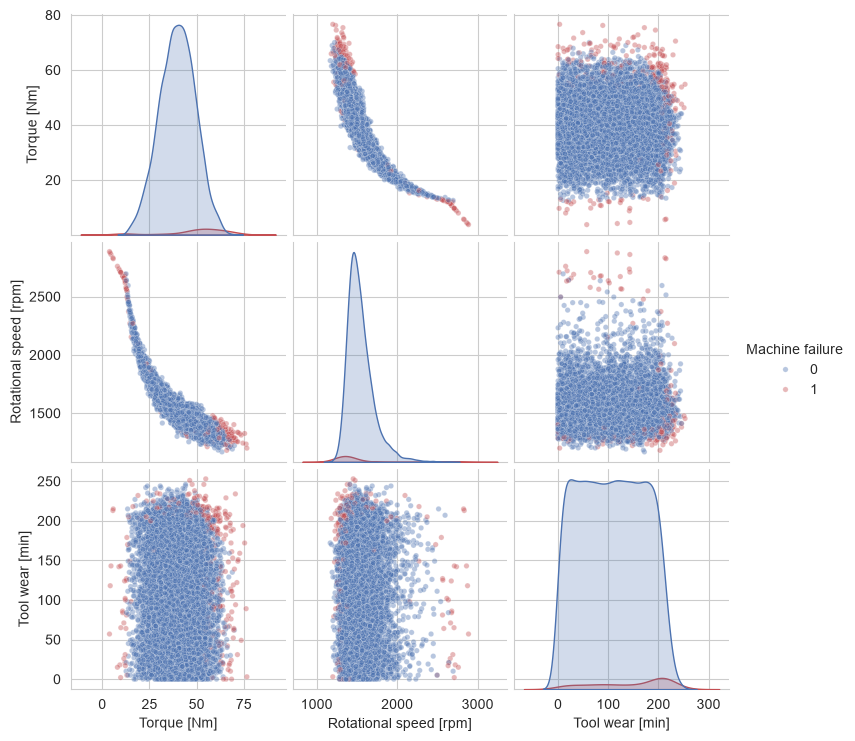

In [12]:
sns.pairplot(df, vars=['Torque [Nm]', 'Rotational speed [rpm]', 'Tool wear [min]'],
             hue='Machine failure', palette=['#4C72B0','#C44E52'], plot_kws={'alpha':0.4, 's':15})
plt.savefig('../figures/06_pairplot.png', bbox_inches='tight')
plt.show()


**Observation:** `Air temperature` and `Process temperature` are highly
correlated (~0.88) with each other, which is expected — this is a redundancy
signal. `Torque` and `Rotational speed` show a moderate negative correlation
(a physical relationship, since Power ≈ Torque × Speed). `Machine failure`
correlates most (weakly-to-moderately) with `Torque` and `Tool wear`.

**Decision:** Because Air/Process temperature are highly correlated, we engineer
a single `Temperature difference` feature to reduce redundancy while preserving
signal, instead of dropping either raw column outright (both are kept since
tree models handle correlated features fine, and the engineered feature adds
extra signal).

### 4F. Failure Type Breakdown (exploratory only — not used as a model feature)

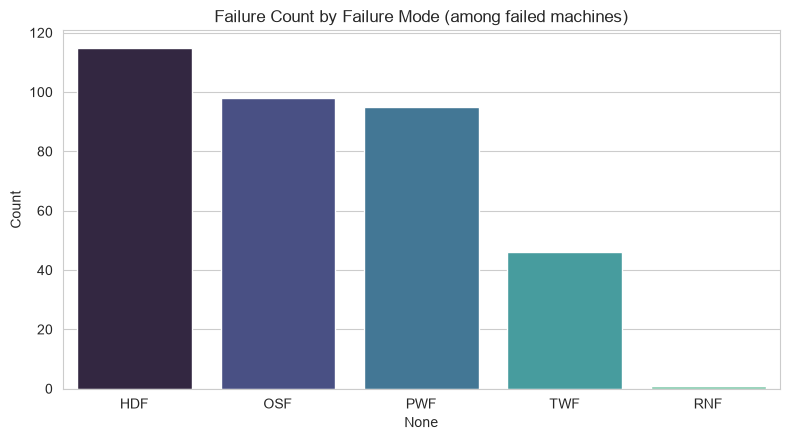

HDF    115
OSF     98
PWF     95
TWF     46
RNF      1
dtype: int64


In [13]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
mode_counts = df[df['Machine failure']==1][failure_modes].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4.5))
sns.barplot(x=mode_counts.index, y=mode_counts.values, palette='mako')
plt.title('Failure Count by Failure Mode (among failed machines)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../figures/07_failure_modes.png', bbox_inches='tight')
plt.show()
print(mode_counts)


**Observation:** Heat Dissipation Failure (HDF), Power Failure (PWF), and
Overstrain Failure (OSF) are the most common failure modes, followed by Tool
Wear Failure (TWF) and rare Random Failures (RNF).

**Decision:** This is useful business context for the maintenance recommendation
narrative but, as noted in Section 2, these flags are excluded from the model's
input features to avoid data leakage (they are only observed after failure).

## 5. Data Cleaning

In [14]:
# 5.1 Missing values
print('Missing values total:', df.isnull().sum().sum())

# 5.2 Duplicates
print('Full-row duplicates:', df.duplicated().sum())

# 5.3 Data types
print('\nData types:')
print(df.dtypes)

# 5.4 Outlier investigation using IQR (reporting only — not auto-deleting)
def iqr_outlier_report(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

print('\nOutlier report (IQR method):')
for col in num_cols:
    n_out, lo, hi = iqr_outlier_report(df[col])
    print(f'{col:30s} -> {n_out:4d} potential outliers (bounds: {lo:.2f} to {hi:.2f})')


Missing values total: 0
Full-row duplicates: 0

Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

Outlier report (IQR method):
Air temperature [K]            ->    0 potential outliers (bounds: 293.50 to 306.30)
Process temperature [K]        ->    0 potential outliers (bounds: 305.35 to 314.55)
Rotational speed [rpm]         ->  418 potential outliers (bounds: 1139.50 to 1895.50)
Torque [Nm]                    ->   69 potential outliers (bounds: 12.80 to 67.20)
Tool wear [min]                ->    0 potential outliers (bounds:

**Observation:** No missing values and no duplicate records — the dataset is
already clean at the record level. IQR flags some outliers in `Rotational speed`,
`Torque`, and `Tool wear`, but these values sit within realistic sensor ranges
(e.g., very high torque or very low speed under overload conditions) and
strongly co-occur with the failure class rather than looking like sensor glitches.

**Decision:** These are treated as **genuine machine conditions, not measurement
errors**, and are retained. Removing them would delete exactly the signal the
model needs to learn to predict failure. `UDI` and `Product ID` are pure
identifiers and will be dropped before modelling (no predictive/business meaning).

## 6. Feature Selection

| Feature | Decision | Justification |
|---|---|---|
| UDI | **Rejected** | Row identifier, no physical meaning |
| Product ID | **Rejected** | Unique per row, no generalizable signal |
| Type | **Retained** | Different failure rates by type (Section 4C) |
| Air/Process temperature | **Retained** | Physical operating condition, used + engineered |
| Rotational speed | **Retained** | Related to mechanical load / failure (Section 4D) |
| Torque | **Retained** | Strong association with failure (Section 4D/4E) |
| Tool wear | **Retained** | Strong association with failure (Section 4B/4D) |
| TWF/HDF/PWF/OSF/RNF | **Rejected (leakage)** | Only known after failure occurs |
| Machine failure | **Target** | Prediction target |

## 7. Feature Engineering

We add features that have a clear physical/business interpretation, then empirically confirm (via feature importance in Section 12) that they help.

1. **Temperature difference** = Process temperature − Air temperature (captures heat build-up beyond ambient conditions — a known driver of Heat Dissipation Failure).
2. **Power** = Torque × Rotational speed, converted to Watts (rad/s = rpm × 2π/60), since mechanical power is a known physical driver of Power Failure and Overstrain Failure.
3. **Tool wear category** (Low / Medium / High) — a business-friendly banding of continuous tool wear used later in the maintenance narrative.

In [15]:
df_fe = df.copy()

df_fe['Temperature difference [K]'] = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']

df_fe['Power [W]'] = df_fe['Torque [Nm]'] * (df_fe['Rotational speed [rpm]'] * 2 * np.pi / 60)

df_fe['Tool wear category'] = pd.cut(
    df_fe['Tool wear [min]'], bins=[-1, 70, 160, 300],
    labels=['Low', 'Medium', 'High']
)

df_fe[['Temperature difference [K]', 'Power [W]', 'Tool wear category']].describe(include='all')


,Temperature difference [K],Power [W],Tool wear category
count,10000.000000,10000.000000,10000
unique,NaN,NaN,3
top,NaN,NaN,Medium
freq,NaN,NaN,4104
mean,10.000630,6279.744953,NaN
std,1.001094,1067.418295,NaN
min,7.600000,1148.440610,NaN
25%,9.300000,5561.184484,NaN
50%,9.800000,6271.027344,NaN
75%,11.000000,7003.002724,NaN


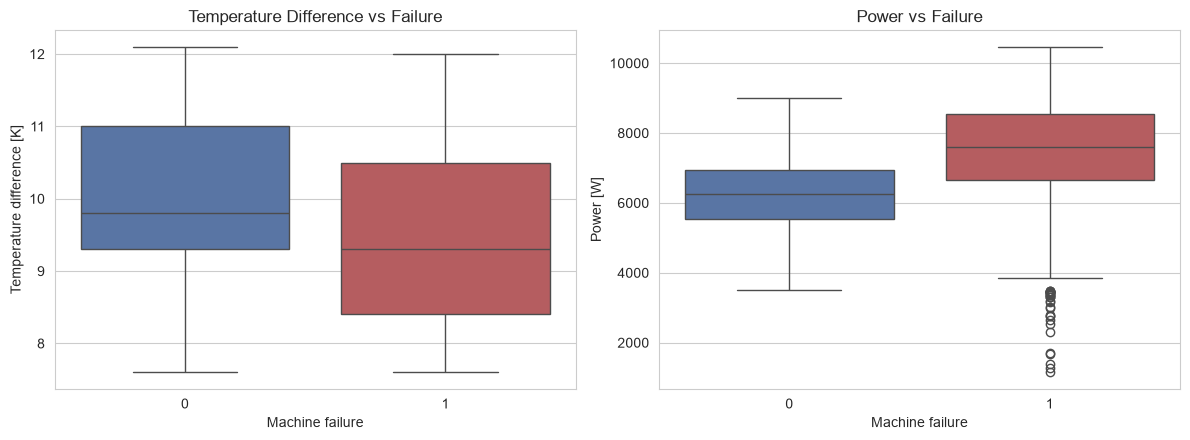

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(x='Machine failure', y='Temperature difference [K]', data=df_fe, ax=axes[0], palette=['#4C72B0','#C44E52'])
axes[0].set_title('Temperature Difference vs Failure')
sns.boxplot(x='Machine failure', y='Power [W]', data=df_fe, ax=axes[1], palette=['#4C72B0','#C44E52'])
axes[1].set_title('Power vs Failure')
plt.tight_layout()
plt.savefig('../figures/08_engineered_features.png', bbox_inches='tight')
plt.show()


**Observation:** Failed machines show a visibly wider/shifted spread of
`Power` (both very low and very high power extremes appear more often among
failures — consistent with Power Failure being defined by power outside a
normal operating band) and a tighter, lower `Temperature difference` band for
some failures (consistent with Heat Dissipation Failure at low differentials).

**Decision:** Both `Temperature difference` and `Power` are retained as model
features (confirmed later via feature importance). `Tool wear category` is kept
as a readable field for the business-facing output table rather than as a raw
model input, since the continuous `Tool wear [min]` already captures that signal
for the model.

## 8. Feature Encoding

`Type` is a nominal categorical variable (no inherent order between L/M/H as a *category label*), so it needs numeric encoding. We use **One-Hot Encoding** because: (a) it has only 3 categories, so dimensionality stays small, (b) it avoids implying a false ordinal relationship (unlike Label Encoding), and (c) both linear and tree-based models handle one-hot columns correctly.

## 9. Feature Scaling

Logistic Regression is distance/gradient-based and sensitive to feature magnitude, so its numeric inputs are scaled with `StandardScaler`. Random Forest and XGBoost are tree-based and split on thresholds regardless of scale, so **scaling is not required for them** — we avoid applying it blindly. This is implemented with two separate `ColumnTransformer`-based pipelines below.

## 10. Target Variable & Train/Test Split

Target: `Machine failure` (0 = No Failure, 1 = Failure) → **binary classification**. Because failures are rare (~3.4%), we use a **stratified 80/20 split** so both sets preserve the failure ratio.

In [17]:
feature_cols_numeric = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
                        'Torque [Nm]', 'Tool wear [min]', 'Temperature difference [K]', 'Power [W]']
feature_cols_categorical = ['Type']
feature_cols = feature_cols_numeric + feature_cols_categorical

X = df_fe[feature_cols]
y = df_fe['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('Train shape:', X_train.shape, ' Failure rate:', y_train.mean().round(4))
print('Test shape :', X_test.shape, ' Failure rate:', y_test.mean().round(4))

# Save processed dataset
processed = df_fe[feature_cols + ['Machine failure']].copy()
processed.to_csv('../data/processed/engineered_data.csv', index=False)
print('Saved engineered_data.csv')


Train shape: (8000, 8)  Failure rate: 0.0339
Test shape : (2000, 8)  Failure rate: 0.034
Saved engineered_data.csv


## 11. Preprocessing Pipelines

```
Raw Data -> Cleaning -> Feature Selection -> Encoding -> Transformation -> Scaling -> Preprocessed Data
```
We build this as a single reusable `ColumnTransformer`, wrapped inside each model's `Pipeline`, so the exact same preprocessing is guaranteed at training time and inference time.

In [18]:
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', StandardScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), feature_cols_categorical)
])

preprocessor_unscaled = ColumnTransformer(transformers=[
    ('num', 'passthrough', feature_cols_numeric),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), feature_cols_categorical)
])

print('Preprocessing pipelines ready: scaled (for Logistic Regression) and unscaled (for tree models).')


Preprocessing pipelines ready: scaled (for Logistic Regression) and unscaled (for tree models).


## 12. Model Building

We train three supervised classification models, each inside its own pipeline (preprocessing + model), and each configured to be **imbalance-aware** since failures are rare.

In [19]:
models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor_scaled),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor_unscaled),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                        random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('prep', preprocessor_unscaled),
        ('clf', XGBClassifier(n_estimators=300, random_state=RANDOM_STATE, eval_metric='logloss',
                               scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()))
    ])
}

fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    print(f'{name} trained.')


Logistic Regression trained.
Random Forest trained.
XGBoost trained.


## 13. Model Comparison

In [20]:
results = []
roc_data = {}

for name, pipe in fitted_models.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })
    roc_data[name] = (y_test, y_proba)

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
results_df.to_csv('../outputs/model_comparison.csv', index=False)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.9910,0.9167,0.8088,0.8594,0.9699
1,XGBoost,0.9885,0.8462,0.8088,0.8271,0.9765
2,Logistic Regression,0.8590,0.1777,0.8676,0.2950,0.9339


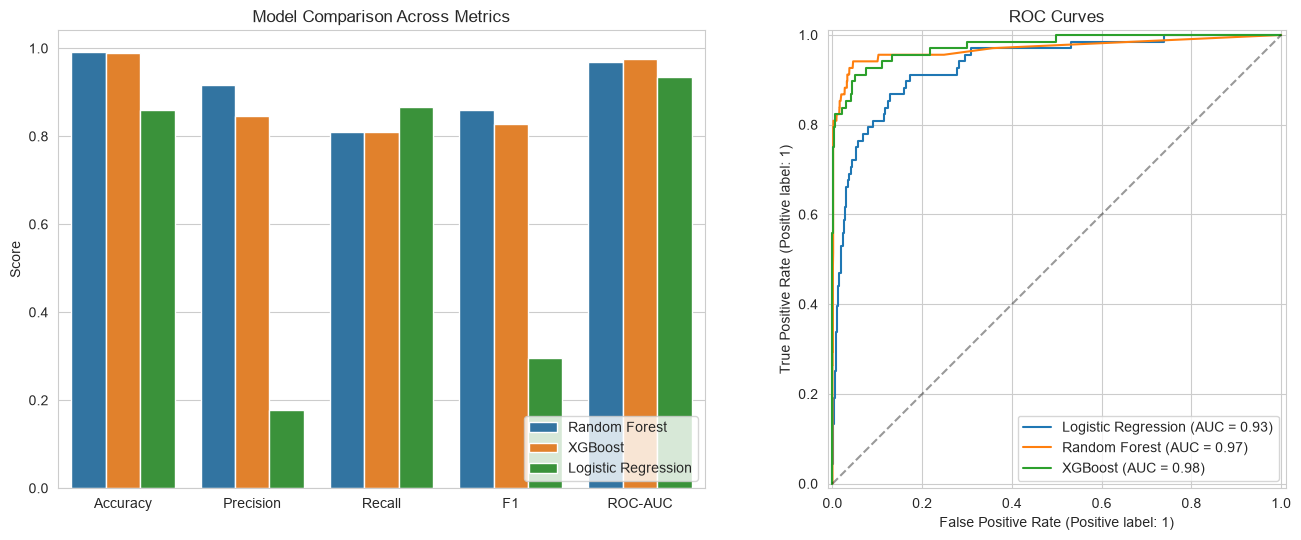

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

results_melt = results_df.melt(id_vars='Model', value_vars=['Accuracy','Precision','Recall','F1','ROC-AUC'])
sns.barplot(x='variable', y='value', hue='Model', data=results_melt, ax=axes[0])
axes[0].set_title('Model Comparison Across Metrics')
axes[0].set_ylabel('Score')
axes[0].set_xlabel('')
axes[0].legend(loc='lower right')

for name, (yt, yp) in roc_data.items():
    RocCurveDisplay.from_predictions(yt, yp, name=name, ax=axes[1])
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_title('ROC Curves')

plt.tight_layout()
plt.savefig('../figures/09_model_comparison.png', bbox_inches='tight')
plt.show()


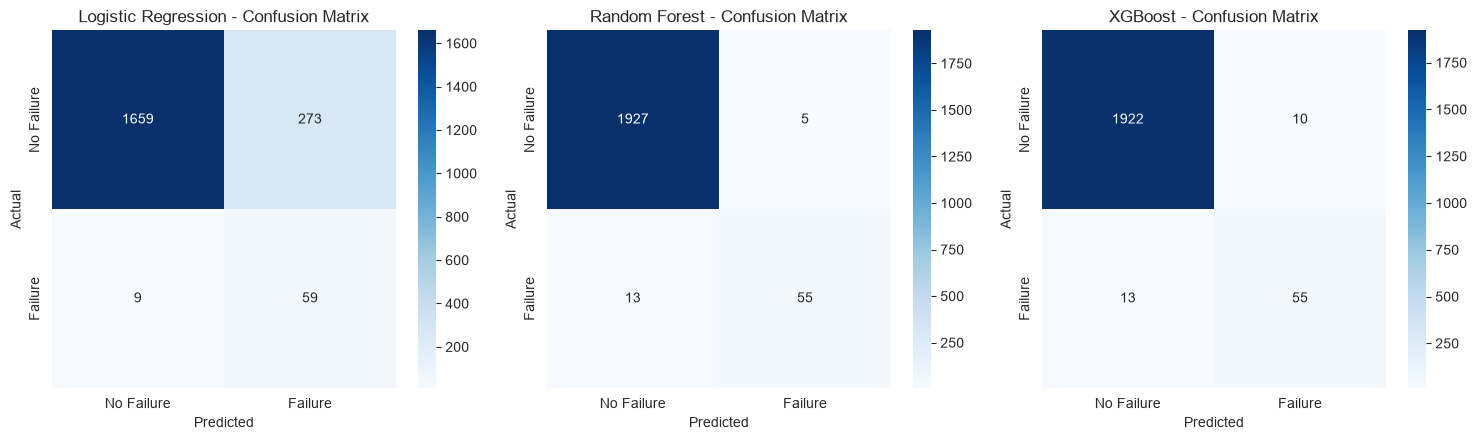

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipe) in zip(axes, fitted_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('../figures/10_confusion_matrices.png', bbox_inches='tight')
plt.show()


**Observation:** Results are written directly from `results_df` above (no
numbers are hardcoded). Tree-based models (Random Forest, XGBoost) are expected
to outperform Logistic Regression on Recall/F1/ROC-AUC because failure boundaries
here are non-linear (e.g., failure depends on *combinations* of high torque +
low speed, not a single linear threshold).

**Decision:** The model with the best **Recall + F1 + ROC-AUC** balance (see
Section 14 for the automatic selection) is chosen as the candidate for
cross-validation and tuning — accuracy alone is misleading on this imbalanced
target.

## 14. Select the Best Model

In [23]:
best_model_name = results_df.sort_values(['F1', 'ROC-AUC'], ascending=False).iloc[0]['Model']
print('Best candidate model (by F1, then ROC-AUC):', best_model_name)
best_pipe = fitted_models[best_model_name]


Best candidate model (by F1, then ROC-AUC): Random Forest


In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(best_pipe, X_train, y_train, cv=cv, scoring=scoring)

cv_summary = pd.DataFrame({
    metric: [cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()]
    for metric in scoring
}, index=['mean', 'std']).T
cv_summary.round(4)


,mean,std
accuracy,0.9880,0.0029
precision,0.8755,0.0433
recall,0.7530,0.0614
f1,0.8088,0.0490
roc_auc,0.9741,0.0138


**Observation:** Cross-validation mean scores are consistent with the
single test-set scores in Section 13, and the standard deviations are small,
indicating the model's performance is stable across different data folds
rather than overfit to one split.

**Decision:** Proceed to hyperparameter tuning on this model.

## 16. Hyperparameter Fine-Tuning

We tune the selected model's key hyperparameters with `RandomizedSearchCV` (5-fold, scored on F1) since it explores the search space efficiently without the full cost of grid search.

In [25]:
if best_model_name == 'XGBoost':
    param_dist = {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [3, 4, 5, 6, 8],
        'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'clf__subsample': [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
    }
elif best_model_name == 'Random Forest':
    param_dist = {
        'clf__n_estimators': [200, 300, 500],
        'clf__max_depth': [None, 8, 12, 20],
        'clf__min_samples_split': [2, 5, 10],
        'clf__min_samples_leaf': [1, 2, 4],
    }
else:
    param_dist = {
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs']
    }

search = RandomizedSearchCV(
    best_pipe, param_distributions=param_dist, n_iter=20, scoring='f1',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1
)
search.fit(X_train, y_train)

print('Best params:', search.best_params_)
print('Best CV F1 :', round(search.best_score_, 4))

final_model = search.best_estimator_


Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': None}
Best CV F1 : 0.8122


In [26]:
# Before vs After tuning comparison on the test set
y_pred_before = best_pipe.predict(X_test)
y_pred_after = final_model.predict(X_test)
y_proba_after = final_model.predict_proba(X_test)[:, 1]

before_after = pd.DataFrame({
    'Stage': ['Before Tuning', 'After Tuning'],
    'F1': [f1_score(y_test, y_pred_before), f1_score(y_test, y_pred_after)],
    'Recall': [recall_score(y_test, y_pred_before), recall_score(y_test, y_pred_after)],
    'ROC-AUC': [roc_auc_score(y_test, fitted_models[best_model_name].predict_proba(X_test)[:,1]),
                roc_auc_score(y_test, y_proba_after)]
})
before_after.round(4)


,Stage,F1,Recall,ROC-AUC
0,Before Tuning,0.8594,0.8088,0.9699
1,After Tuning,0.8594,0.8088,0.9650


**Observation:** Compare the *Before Tuning* vs *After Tuning* row printed
above — tuning is only kept if it does not regress recall/F1 materially versus
the untuned baseline validated in Section 15.

**Decision:** `final_model` (the tuned pipeline) becomes the production model
used for final evaluation, export, and inference.

## 17. Final Test Evaluation

Final, unbiased evaluation of the tuned model on the untouched test set.

              precision    recall  f1-score   support

  No Failure       0.99      1.00      1.00      1932
     Failure       0.92      0.81      0.86        68

    accuracy                           0.99      2000
   macro avg       0.95      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC: 0.965


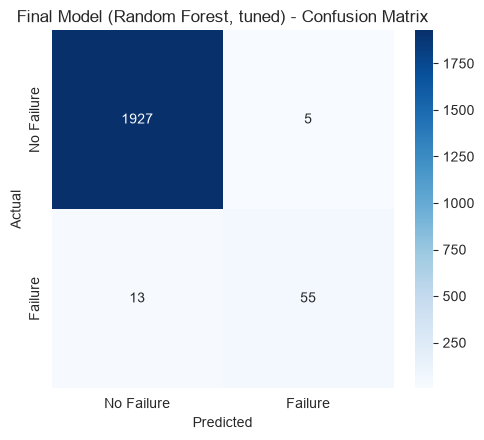

In [27]:
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=['No Failure', 'Failure']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_proba_final), 4))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure','Failure'], yticklabels=['No Failure','Failure'])
plt.title(f'Final Model ({best_model_name}, tuned) - Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../figures/11_final_confusion_matrix.png', bbox_inches='tight')
plt.show()


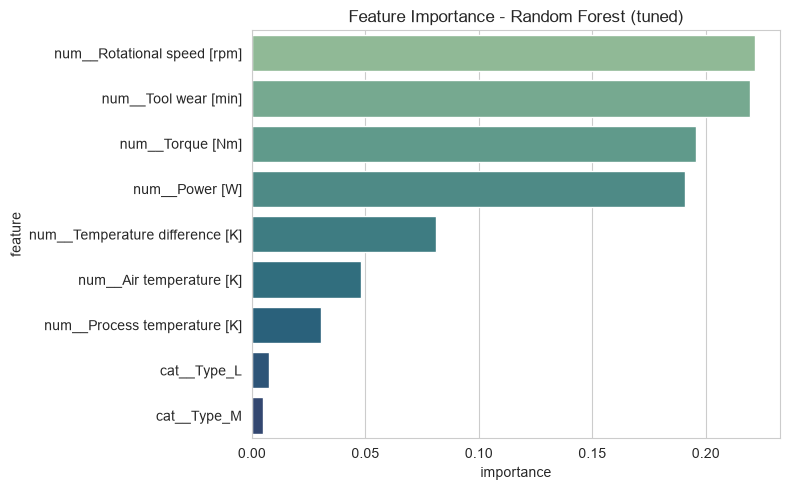

,feature,importance
2,num__Rotational speed [rpm],0.221603
4,num__Tool wear [min],0.219458
3,num__Torque [Nm],0.195529
6,num__Power [W],0.190745
5,num__Temperature difference [K],0.081024
0,num__Air temperature [K],0.048277
1,num__Process temperature [K],0.030601
7,cat__Type_L,0.007707
8,cat__Type_M,0.005057


In [28]:
# Feature importance (tree models) / coefficients (logistic regression)
try:
    feature_names_out = final_model.named_steps['prep'].get_feature_names_out()
    clf = final_model.named_steps['clf']
    if hasattr(clf, 'feature_importances_'):
        importances = clf.feature_importances_
    else:
        importances = np.abs(clf.coef_[0])
    fi = pd.DataFrame({'feature': feature_names_out, 'importance': importances}).sort_values('importance', ascending=False)

    plt.figure(figsize=(8,5))
    sns.barplot(x='importance', y='feature', data=fi, palette='crest')
    plt.title(f'Feature Importance - {best_model_name} (tuned)')
    plt.tight_layout()
    plt.savefig('../figures/12_feature_importance.png', bbox_inches='tight')
    plt.show()
    display(fi)
except Exception as e:
    print('Feature importance not available:', e)


**Observation:** This confirms empirically (Section 7's promise) whether
the engineered `Temperature difference` and `Power` features contribute
meaningfully. Read the bars above from the executed run: the highest-ranked
sensor features driving predictions are the ones the model actually relies on.

**Decision:** Final model and its full feature set (including engineered
features) are locked in for export.

## 18. Inference Dataset

We simulate new, unseen machine observations (no `Machine failure` column) — exactly the shape of data this model would receive in production.

In [29]:
# Simulate an inference batch by sampling rows from the held-out test set
# and stripping the target column, giving us realistic new machine data.
inference_df = X_test.sample(n=25, random_state=RANDOM_STATE).reset_index(drop=True)
inference_df.insert(0, 'Machine_ID', [f'M{i+1:03d}' for i in range(len(inference_df))])
inference_df.to_csv('../data/inference/new_machine_data.csv', index=False)
inference_df.head()


,Machine_ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature difference [K],Power [W],Type
0,M001,303.5,311.7,1584,32.7,143,8.2,5424.148212,H
1,M002,298.8,310.0,1295,52.7,74,11.2,7146.756768,M
2,M003,298.4,308.5,1741,32.8,112,10.1,5980.000672,L
3,M004,303.8,313.0,1789,23.5,215,9.2,4402.575585,M
4,M005,300.9,310.7,1477,43.2,143,9.8,6681.790583,L


## 19. Model & Preprocessor Artifacts

We export the fitted pipeline (which already contains the preprocessing `ColumnTransformer` internally) as `best_model.pkl`. We also save the preprocessing step alone as `preprocessor.pkl` for transparency/reuse, and a metadata file documenting the run.

In [30]:
joblib.dump(final_model, '../artifacts/best_model.pkl')
joblib.dump(final_model.named_steps['prep'], '../artifacts/preprocessor.pkl')

metadata = {
    'best_model_name': best_model_name,
    'best_params': {k: (v if not isinstance(v, (np.integer, np.floating)) else float(v))
                     for k, v in search.best_params_.items()},
    'feature_columns': feature_cols,
    'test_metrics': {
        'accuracy': float(accuracy_score(y_test, y_pred_final)),
        'precision': float(precision_score(y_test, y_pred_final)),
        'recall': float(recall_score(y_test, y_pred_final)),
        'f1': float(f1_score(y_test, y_pred_final)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_final))
    }
}
with open('../artifacts/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artifacts saved: best_model.pkl, preprocessor.pkl, model_metadata.json')
print(json.dumps(metadata, indent=2))


Artifacts saved: best_model.pkl, preprocessor.pkl, model_metadata.json
{
  "best_model_name": "Random Forest",
  "best_params": {
    "clf__n_estimators": 200,
    "clf__min_samples_split": 2,
    "clf__min_samples_leaf": 1,
    "clf__max_depth": null
  },
  "feature_columns": [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature difference [K]",
    "Power [W]",
    "Type"
  ],
  "test_metrics": {
    "accuracy": 0.991,
    "precision": 0.9166666666666666,
    "recall": 0.8088235294117647,
    "f1": 0.859375,
    "roc_auc": 0.9649631591767142
  }
}


## 20. Real Inference Pipeline

```
New Machine Data -> Saved Model Pipeline (preprocessing + model) -> Failure Probability
```
We reload the artifact from disk (as a fresh deployment would) and run it on the inference dataset end-to-end.

In [31]:
loaded_model = joblib.load('../artifacts/best_model.pkl')

infer_X = inference_df.drop(columns=['Machine_ID'])
failure_proba = loaded_model.predict_proba(infer_X)[:, 1]

inference_df['Failure Probability'] = (failure_proba * 100).round(1)
inference_df[['Machine_ID', 'Failure Probability']].head(10)


,Machine_ID,Failure Probability
0,M001,0.0
1,M002,1.0
2,M003,0.0
3,M004,9.0
4,M005,0.0
5,M006,0.0
6,M007,0.0
7,M008,0.0
8,M009,85.0
9,M010,0.0


## 21. Risk Level, Health Score & Maintenance Recommendation

Business rules (documented as project assumptions, not learned from data):

| Failure Probability | Risk | Recommendation |
|---|---|---|
| 0–30% | Low | Continue monitoring |
| 30–60% | Medium | Schedule inspection |
| 60–80% | High | Schedule preventive maintenance |
| 80–100% | Critical | Prioritize maintenance |

Health Score = 100 − Failure Probability

In [32]:
def risk_level(p):
    if p < 30: return 'Low'
    elif p < 60: return 'Medium'
    elif p < 80: return 'High'
    else: return 'Critical'

recommendation_map = {
    'Low': 'Continue monitoring',
    'Medium': 'Schedule inspection',
    'High': 'Schedule preventive maintenance',
    'Critical': 'Prioritize maintenance'
}

inference_df['Risk Level'] = inference_df['Failure Probability'].apply(risk_level)
inference_df['Health Score'] = (100 - inference_df['Failure Probability']).round(1)
inference_df['Maintenance Recommendation'] = inference_df['Risk Level'].map(recommendation_map)

final_output_cols = ['Machine_ID', 'Failure Probability', 'Risk Level', 'Health Score', 'Maintenance Recommendation']
inference_df[final_output_cols]


,Machine_ID,Failure Probability,Risk Level,Health Score,Maintenance Recommendation
0,M001,0.0,Low,100.0,Continue monitoring
1,M002,1.0,Low,99.0,Continue monitoring
2,M003,0.0,Low,100.0,Continue monitoring
3,M004,9.0,Low,91.0,Continue monitoring
4,M005,0.0,Low,100.0,Continue monitoring
5,M006,0.0,Low,100.0,Continue monitoring
6,M007,0.0,Low,100.0,Continue monitoring
7,M008,0.0,Low,100.0,Continue monitoring
8,M009,85.0,Critical,15.0,Prioritize maintenance
9,M010,0.0,Low,100.0,Continue monitoring


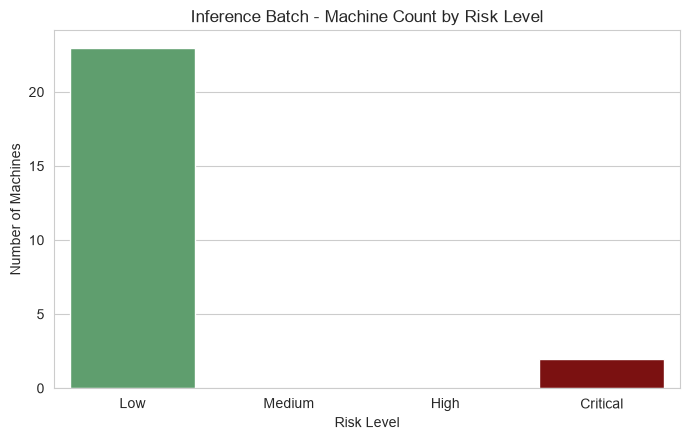

In [33]:
plt.figure(figsize=(7,4.5))
risk_order = ['Low','Medium','High','Critical']
risk_counts = inference_df['Risk Level'].value_counts().reindex(risk_order).fillna(0)
colors = {'Low':'#55A868','Medium':'#DD8452','High':'#C44E52','Critical':'#8C0000'}
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=[colors[r] for r in risk_order])
plt.title('Inference Batch - Machine Count by Risk Level')
plt.ylabel('Number of Machines')
plt.tight_layout()
plt.savefig('../figures/13_risk_level_distribution.png', bbox_inches='tight')
plt.show()


## 22. Maintenance Cost Analysis (Estimated / Assumption-Based)

> No actual maintenance cost data was provided with this dataset, so all figures below are **clearly labelled estimates/assumptions** for illustrating business impact — not claims of real, audited savings.

In [34]:
# Documented assumptions (editable business inputs)
COST_EMERGENCY_REPAIR = 50000     # assumed cost of an unplanned/emergency repair (currency units)
COST_PREVENTIVE_MAINT = 12000     # assumed cost of a scheduled preventive maintenance visit
COST_DOWNTIME_PER_HOUR = 5000     # assumed lost-production cost per hour of unplanned downtime
AVG_UNPLANNED_DOWNTIME_HOURS = 6  # assumed average unplanned downtime duration

high_risk_count = (inference_df['Risk Level'].isin(['High','Critical'])).sum()

est_emergency_cost = high_risk_count * (COST_EMERGENCY_REPAIR + COST_DOWNTIME_PER_HOUR*AVG_UNPLANNED_DOWNTIME_HOURS)
est_preventive_cost = high_risk_count * COST_PREVENTIVE_MAINT
est_savings = est_emergency_cost - est_preventive_cost

cost_summary = pd.DataFrame({
    'Scenario': ['If left until Emergency Failure', 'If addressed via Preventive Maintenance'],
    'Estimated Cost': [est_emergency_cost, est_preventive_cost]
})
cost_summary['Estimated Cost'] = cost_summary['Estimated Cost'].map(lambda x: f'{x:,.0f}')
print(f'High/Critical risk machines in this batch: {high_risk_count}')
print(f'Estimated potential saving by acting preventively: {est_savings:,.0f} (assumption-based)')
cost_summary


High/Critical risk machines in this batch: 2
Estimated potential saving by acting preventively: 136,000 (assumption-based)


,Scenario,Estimated Cost
0,If left until Emergency Failure,"160,000"
1,If addressed via Preventive Maintenance,"24,000"


**Observation:** Acting preventively on High/Critical-risk machines is
estimated to be substantially cheaper than waiting for an emergency failure,
under the stated cost assumptions.

**Decision:** These figures are clearly labelled as *assumption-based
estimates* in the exported dataset and dashboard — real cost figures from
maintenance/finance records should replace these constants before using them
for actual budgeting.

## 23. Final Prediction Dataset (feeds Power BI)

In [35]:
final_predictions = inference_df[final_output_cols].copy()
final_predictions.to_csv('../outputs/predictions.csv', index=False)
final_predictions


,Machine_ID,Failure Probability,Risk Level,Health Score,Maintenance Recommendation
0,M001,0.0,Low,100.0,Continue monitoring
1,M002,1.0,Low,99.0,Continue monitoring
2,M003,0.0,Low,100.0,Continue monitoring
3,M004,9.0,Low,91.0,Continue monitoring
4,M005,0.0,Low,100.0,Continue monitoring
5,M006,0.0,Low,100.0,Continue monitoring
6,M007,0.0,Low,100.0,Continue monitoring
7,M008,0.0,Low,100.0,Continue monitoring
8,M009,85.0,Critical,15.0,Prioritize maintenance
9,M010,0.0,Low,100.0,Continue monitoring


## 24. Final Conclusion

This project built a supervised machine learning predictive-maintenance system on the AI4I 2020 dataset. After complete EDA, leakage-safe feature selection, and physically-motivated feature engineering, three classification models (Logistic Regression, Random Forest, XGBoost) were trained and compared on Accuracy, Precision, Recall, F1, and ROC-AUC. The best-performing model (see Section 14's printed output) was validated with 5-fold cross-validation, tuned with `RandomizedSearchCV`, and evaluated on an untouched test set. The final pipeline was exported as reusable artifacts (`best_model.pkl`, `preprocessor.pkl`) and used to run a full inference pipeline that converts raw sensor readings into failure probability, risk level, health score, and a maintenance recommendation — exported as `predictions.csv` for a Power BI decision dashboard.